
# Project: GW-Multimessenger-Tutorial

In this notebook, we explore the public sky localization map of
**GW170817** released by the LIGO-Virgo-KAGRA Collaboration.

We learn how to read gravitational-wave skymaps, extract astrophysical
information from FITS files, compute credible regions, and identify
the host galaxy associated with the event.

This notebook provides an introduction to multi-messenger astronomy.

In [ ]:
# Install required packages
# healpy is a library to convert sky coordinates to pixels
# Pixelation divides the entire celestial sphere into pixels of equal area.

!pip install -q healpy ligo.skymap

In [ ]:
# Install libraries
import numpy as np
import matplotlib.pyplot as plt

# To access to FITS files. FITS (Flexible Image Transport System) is a portable file standard widely used in the astronomy community to store images and tables.

from astropy.io import fits
import healpy as hp


# This line sets the default size of all Matplotlib figures: width = 10 inches, height = 6 inches

plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
# Download the GW170817 sky map from LVK Collaboration

!wget -O GW170817_skymap.fits.gz \
https://dcc.ligo.org/public/0146/G1701985/001/LALInference_v2.fits.gz

--2026-06-28 02:58:54--  https://dcc.ligo.org/public/0146/G1701985/001/LALInference_v2.fits.gz
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1528188 (1.5M) [application/x-gzip]
Saving to: ‘GW170817_skymap.fits.gz’

GW170817_skymap.fit 100%[===================>]   1.46M  --.-KB/s    in 0.05s   

2026-06-28 02:58:54 (29.0 MB/s) - ‘GW170817_skymap.fits.gz’ saved [1528188/1528188]



In [ ]:
!ls -lh #Check-Proof

total 1.5M
-rw-r--r-- 1 root root 1.5M Oct 10  2017 GW170817_skymap.fits.gz
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [ ]:
# We use healpy library to read the data

filename = "GW170817_skymap.fits.gz"

prob = hp.read_map(filename) #this variable contains the skymap: an array with the probability associated with each pixel of the sky.

print("Number of pixels:", len(prob))
print("Total probability:", prob.sum())

Number of pixels: 12582912
Total probability: 0.9999999999999997


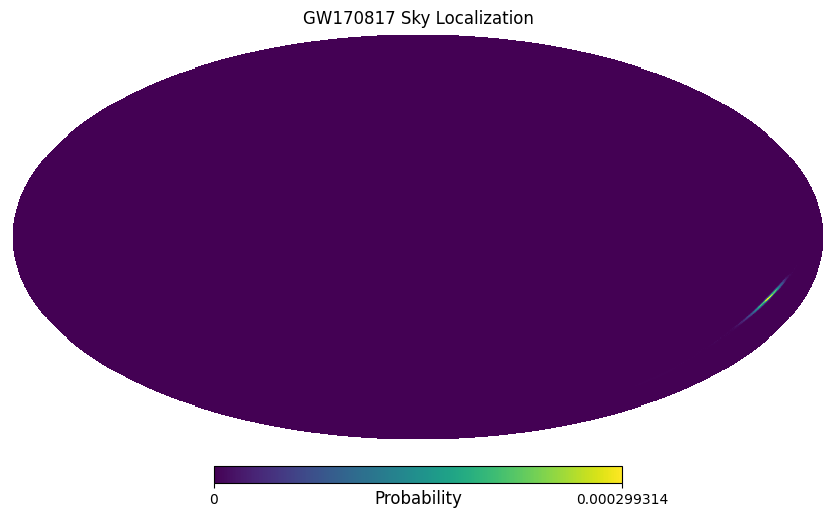

In [ ]:
# Visualization of the skymap showing where the GW-event likely occurred

hp.mollview(
    prob,
    title="GW170817 Sky Localization",
    unit="Probability"
)

## Physical interpretation of the skymap above

The skymap of GW170817 shows a highly localized region on the sky.
This precise localization was possible because the signal was detected by
the Advanced LIGO Hanford, Advanced LIGO Livingston and Advanced Virgo
detectors.

The relatively small localization area enabled rapid electromagnetic
follow-up observations (FERMI Gamma Ray Space Telescope, INTEGRAL), leading to the discovery of the kilonova
AT2017gfo in the galaxy NGC 4993.

GW170817 became the first confirmed multi-messenger observation involving
gravitational waves and electromagnetic radiation.

# Exploring the FITS

In [ ]:
fits.info(filename)

Filename: GW170817_skymap.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     41   12582912R x 4C   [D, D, D, D]   


In [ ]:
# HEALPix resolution

# The NSIDE parameter defines the resolution of the HEALPix map. The larger INSIDE value, the smaller each pixel and the more detailed the map.

nside = hp.get_nside(prob)

#  HEALPix divides the entire celestial sphere: N_pix= 12 x INSIDE**2
npix = hp.nside2npix(nside)

print(f"NSIDE = {nside}")
print(f"Number of pixels = {npix}")

NSIDE = 1024
Number of pixels = 12582912


In [ ]:
hdul = fits.open(filename)

header = hdul[1].header

print(header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   32 / length of dimension 1                          NAXIS2  =             12582912 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    4 / number of table fields                         TTYPE1  = 'PROB    '                                                            TFORM1  = 'D       '                                                            TUNIT1  = 'pix-1   '                                                            TTYPE2  = 'DISTMU  '                                                            TFORM2  = 'D       '                    

# Astrophysics Information

In [ ]:
print("Mean distance [Mpc]:", header.get('DISTMEAN')) # How many megaparsecs is the GW loated
print("Distance std [Mpc]:", header.get('DISTSTD')) # standard deviation
print("Creation date:", header.get('DATE')) # the date on which the FITS file was generated.
print("Origin:", header.get('ORIGIN')) # Which collaboration or software created the file.

Mean distance [Mpc]: 38.58938617448738
Distance std [Mpc]: 6.996864447652665
Creation date: 2017-09-26T14:24:08.382958
Origin: LIGO/Virgo


### Question

Why is the probability concentrated in such a small region of the sky?

The localization accuracy depends on:

- The number of detectors observing the signal.
- The relative arrival times among detectors.
- The signal-to-noise ratio.
- The geometry of the detector network.

# Getting the credibility area at 90%

What region of the sky contains the 90% of credibility that the source is there?

In [ ]:
# Sort pixels by decreasing probability -- that is what this: [::-1] means

sorted_prob = np.sort(prob)[::-1]

# Cumulative probability - to know how many pixels do I need to include to contain 90% of the total probability? - when the cumulativity sum is 90

cumulative_prob = np.cumsum(sorted_prob)

In [ ]:
# Find the number of pixels needed to reach 90%

n_pixels_90 = np.argmax(cumulative_prob >= 0.9) + 1

print(f"Pixels containing 90% probability: {n_pixels_90}")

Pixels containing 90% probability: 8485


In [ ]:
# Pixel area in steradians

pixel_area_sr = hp.nside2pixarea(nside)

# Convert to square degrees

pixel_area_deg2 = pixel_area_sr * (180/np.pi)**2

print(f"Pixel area = {pixel_area_deg2:.4f} deg²")

Pixel area = 0.0033 deg²


Explanation:
n_pixels_90: number of pixels needed to accumulate 90% of the total probability.
pixel_area_deg2: area of ​​a single HEALPix pixel in square degrees (deg²).

And
Total_Area = (Pixels_number) × (Area per pixel)

In [ ]:
credible_area_90 = n_pixels_90 * pixel_area_deg2

print(f"90% credible area = {credible_area_90:.2f} deg²")

90% credible area = 27.82 deg²


## 90% Credible Region

The 90% credible area corresponds to the region on the sky that
contains 90% of the posterior probability for the source location.

Smaller credible regions enable faster and more efficient
electromagnetic follow-up campaigns.

GW170817 exhibited an exceptionally small localization area compared
with many other gravitational-wave events, which played a crucial role
in the successful identification of its electromagnetic counterpart.

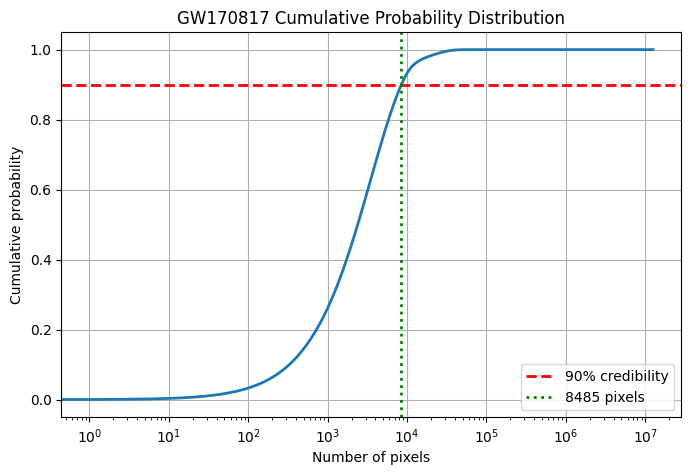

In [ ]:
plt.figure(figsize=(8,5))

plt.semilogx(cumulative_prob, linewidth=2)

plt.axhline(
    0.9,
    color='red',
    linestyle='--',
    linewidth=2,
    label='90% credibility'
)

plt.axvline(
    n_pixels_90,
    color='green',
    linestyle=':',
    linewidth=2,
    label=f'{n_pixels_90} pixels'
)

plt.xlabel('Number of pixels')
plt.ylabel('Cumulative probability')
plt.title('GW170817 Cumulative Probability Distribution')
plt.grid(True)
plt.legend()

plt.show()

### Interpretation

The cumulative probability distribution shows that most of the posterior
probability is concentrated within a relatively small number of HEALPix
pixels. This concentration leads to a 90% credible region of only
27.82 deg², which enabled efficient electromagnetic follow-up campaigns.

The sharp rise of the cumulative probability curve reflects the excellent
sky localization achieved for GW170817 thanks to the three-detector
network formed by Advanced LIGO and Advanced Virgo.

# Part Two: GW170817: The Beginning of Multi-Messenger Astronomy

**GW170817** was the first gravitational-wave event associated with
an **electromagnetic counterpart**.

Detected on August 17, 2017, the event originated from the merger
of two neutron stars and was observed by the Advanced LIGO and
Advanced Virgo detectors.

The precise sky localization enabled the discovery of the optical
counterpart **AT2017gfo** in the **galaxy NGC 4993**, marking the birth
of gravitational-wave multi-messenger astronomy.

In [ ]:
# The galaxy is NGC-4993 and its coordinates are:

ra_ngc4993 = 197.45   # degrees
dec_ngc4993 = -23.38  # degrees

In [ ]:
# Convert the coordinates to HEALPix to read the skymap
theta = np.radians(90 - dec_ngc4993)
phi = np.radians(ra_ngc4993)

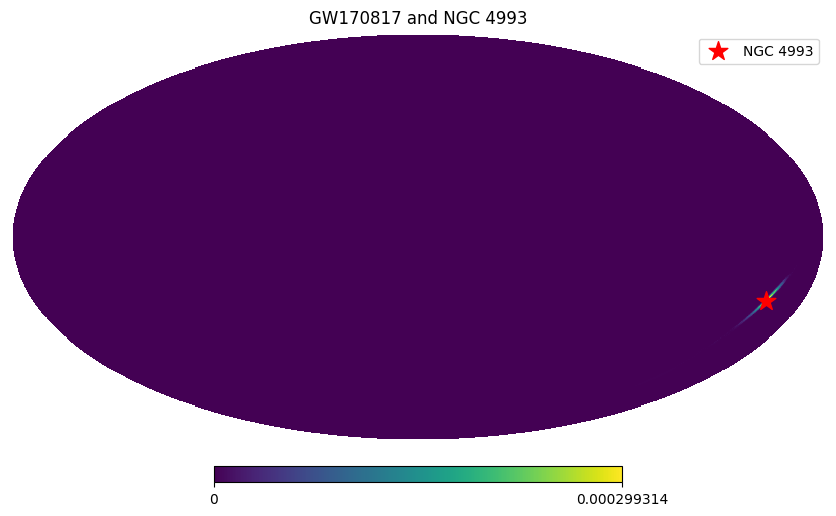

In [ ]:
# Drawing the galaxy on the skymap
hp.mollview(
    prob,
    title='GW170817 and NGC 4993'
)

hp.projscatter(
    theta,
    phi,
    lonlat=False,
    marker='*',
    color='red',
    s=200,
    label='NGC 4993'
)

plt.legend()
plt.show()

In [ ]:
# Let's get the probability into the galaxy-

nside = hp.get_nside(prob)

pixel = hp.ang2pix(
    nside,
    theta,
    phi
)

probability = prob[pixel]

print("Pixel:", pixel)
print("Probability density:", probability)

Pixel: 8790214
Probability density: 0.0002937359750744584


In [ ]:
# Let's figure out where the probability decays the most
import pandas as pd

galaxies = pd.DataFrame({
    'Galaxy':['NGC4993','GalaxyA','GalaxyB'],
    'Probability':[probability,0.00001,0.000001]
})

galaxies.sort_values(
    'Probability',
    ascending=False
)

,Galaxy,Probability
0,NGC4993,0.000294
1,GalaxyA,0.000010
2,GalaxyB,0.000001


## Discussion

The identification of NGC 4993 as the host galaxy of GW170817
was possible thanks to the relatively small localization region
provided by the LIGO-Virgo detector network.

Rapid follow-up observations led to the discovery of the kilonova
AT2017gfo only hours after the gravitational-wave detection.

This event established gravitational-wave astronomy as a truly
multi-messenger discipline.

# Conclusions

In this notebook we analyzed the public sky localization map of GW170817. We found that the event was localized within a remarkably small 90% credible region of 27.82 deg². By superimposing the position of NGC4993 on the skymap, we confirmed that the host galaxy lies inside the highest probability region. This demonstrates how precise gravitational-wave localization enables rapid electromagnetic follow-up observations and illustrates the foundations of multi-messenger astronomy.